In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

AUDIO_PATH = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/hendrix/"
COMP_PATH  = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/comparacao/"
CREAM_PATH = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/cream/"
POLICE_PATH= "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/the_police/"
ZZTOP_PATH = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/zz_top/"
SRV_PATH   = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/srv/"

def extrair_features(path, arquivo):
    y, sr = librosa.load(path + arquivo, duration=60)
    D = librosa.stft(y)
    mag = np.abs(D)
    freqs = librosa.fft_frequencies(sr=sr)
    return {
        "Sub-grave":      mag[(freqs >= 20)  & (freqs < 80)].mean(),
        "Grave/Baixo":    mag[(freqs >= 80)  & (freqs < 300)].mean(),
        "Médio/Guitarra": mag[(freqs >= 300) & (freqs < 2000)].mean(),
        "Médio-Agudo":    mag[(freqs >= 2000)& (freqs < 6000)].mean(),
        "Agudo/Pratos":   mag[(freqs >= 6000)& (freqs < 20000)].mean(),
    }

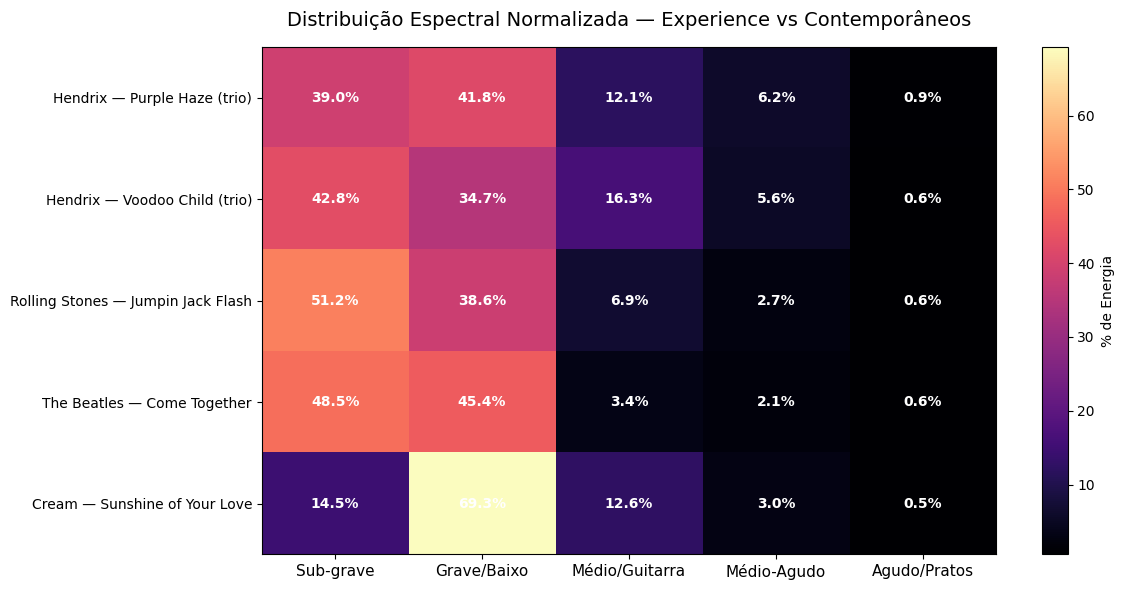

In [2]:
comparacao = {
    "Hendrix — Purple Haze (trio)":       (AUDIO_PATH, "purple_haze.mp3"),
    "Hendrix — Voodoo Child (trio)":      (AUDIO_PATH, "voodoo_child.mp3"),
    "Rolling Stones — Jumpin Jack Flash": (COMP_PATH,  "jumpin_jack_flash.mp3"),
    "The Beatles — Come Together":        (COMP_PATH,  "come_together.mp3"),
    "Cream — Sunshine of Your Love":      (CREAM_PATH, "sunshine_of_your_love.mp3"),
}

rows = []
for nome, (path, arquivo) in comparacao.items():
    feat = extrair_features(path, arquivo)
    feat["Banda/Faixa"] = nome
    rows.append(feat)

df_comp = pd.DataFrame(rows).set_index("Banda/Faixa")
df_comp_pct = df_comp.div(df_comp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(df_comp_pct.values, aspect="auto", cmap="magma")
ax.set_xticks(range(len(df_comp_pct.columns)))
ax.set_xticklabels(df_comp_pct.columns, fontsize=11)
ax.set_yticks(range(len(df_comp_pct.index)))
ax.set_yticklabels(df_comp_pct.index, fontsize=10)
for i in range(len(df_comp_pct.index)):
    for j in range(len(df_comp_pct.columns)):
        ax.text(j, i, f"{df_comp_pct.values[i,j]:.1f}%",
                ha="center", va="center", color="white", fontsize=10, fontweight="bold")
plt.colorbar(im, ax=ax, label="% de Energia")
plt.title("Distribuição Espectral Normalizada — Experience vs Contemporâneos", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [3]:
todos_trios = {
    "Hendrix Experience": [
        (AUDIO_PATH, "purple_haze.mp3"),
        (AUDIO_PATH, "voodoo_child.mp3"),
        (AUDIO_PATH, "littlewing.mp3"),
        (AUDIO_PATH, "all_allong_the_watchtower.mp3"),
    ],
    "Cream": [
        (CREAM_PATH, "sunshine_of_your_love.mp3"),
        (CREAM_PATH, "white_room.mp3"),
        (CREAM_PATH, "crossroads.mp3"),
        (CREAM_PATH, "badge.mp3"),
    ],
    "The Police": [
        (POLICE_PATH, "roxanne.mp3"),
        (POLICE_PATH, "every_breath_you_take.mp3"),
        (POLICE_PATH, "message_in_a_bottle.mp3"),
        (POLICE_PATH, "synchronicity_ii.mp3"),
    ],
    "ZZ Top": [
        (ZZTOP_PATH, "sharp_dressed_man.mp3"),
        (ZZTOP_PATH, "la_grange.mp3"),
        (ZZTOP_PATH, "legs.mp3"),
        (ZZTOP_PATH, "gimme_all_your_lovin.mp3"),
    ],
    "SRV & Double Trouble": [
        (SRV_PATH, "pride_and_joy.mp3"),
        (SRV_PATH, "texas_flood.mp3"),
        (SRV_PATH, "couldnt_stand_the_weather.mp3"),
        (SRV_PATH, "the_sky_is_crying.mp3"),
    ],
}

medias_trios = {}
for trio, faixas in todos_trios.items():
    features = [extrair_features(path, arquivo) for path, arquivo in faixas]
    medias_trios[trio] = pd.DataFrame(features).mean()

df_trios = pd.DataFrame(medias_trios).T
df_trios_pct = df_trios.div(df_trios.sum(axis=1), axis=0) * 100

print("DNA Espectral médio por trio:")
print(df_trios_pct.round(1).to_string())

DNA Espectral médio por trio:
                      Sub-grave  Grave/Baixo  Médio/Guitarra  Médio-Agudo  Agudo/Pratos
Hendrix Experience    36.700001    45.099998            12.0          5.0           1.3
Cream                 19.700001    61.400002            14.1          3.5           1.3
The Police            38.900002    44.700001            11.4          3.4           1.5
ZZ Top                46.900002    36.599998            11.0          4.2           1.2
SRV & Double Trouble  46.900002    42.900002             6.8          2.6           0.8


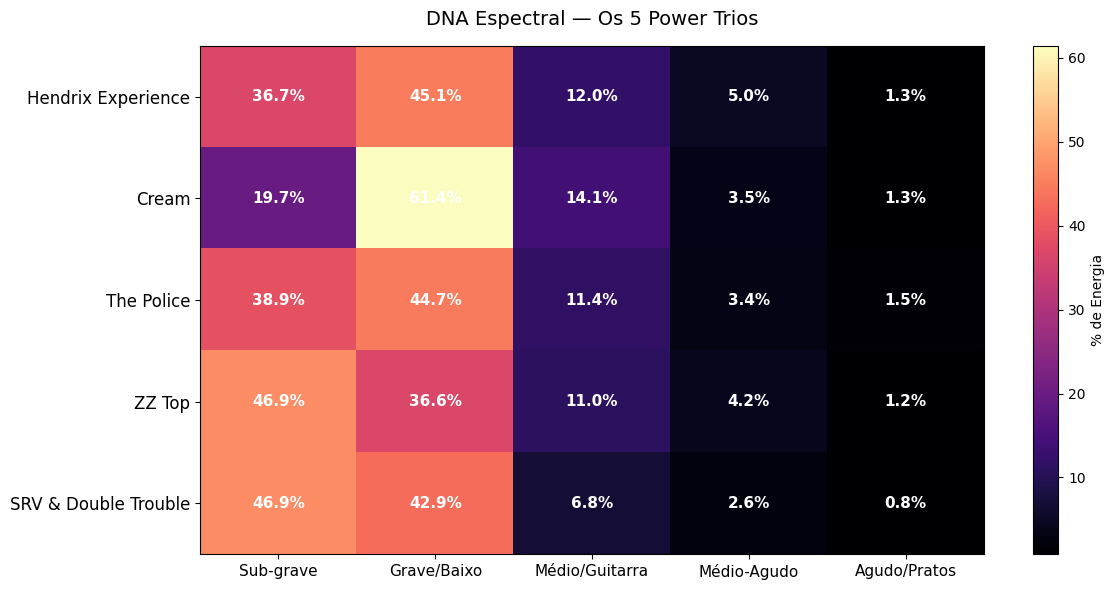

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(df_trios_pct.values, aspect="auto", cmap="magma")
ax.set_xticks(range(len(df_trios_pct.columns)))
ax.set_xticklabels(df_trios_pct.columns, fontsize=11)
ax.set_yticks(range(len(df_trios_pct.index)))
ax.set_yticklabels(df_trios_pct.index, fontsize=12)
for i in range(len(df_trios_pct.index)):
    for j in range(len(df_trios_pct.columns)):
        ax.text(j, i, f"{df_trios_pct.values[i,j]:.1f}%",
                ha="center", va="center", color="white", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="% de Energia")
plt.title("DNA Espectral — Os 5 Power Trios", fontsize=14, pad=15)
plt.tight_layout()
plt.show()